In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [4]:
df = pd.read_csv("Iris.csv")

In [5]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df = df.iloc[:,1:]

In [7]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
encoder = LabelEncoder()

In [10]:
df['Species'] = encoder.fit_transform(df['Species'])

In [11]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

In [13]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

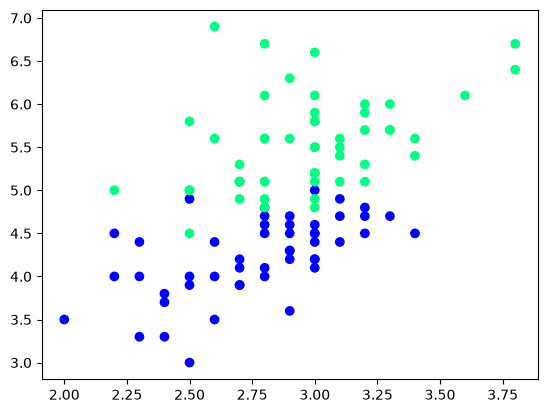

In [15]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [16]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
75,3.0,4.4,1
91,3.0,4.6,1
93,2.3,3.3,1
52,3.1,4.9,1
83,2.7,5.1,1
107,2.9,6.3,2
64,2.9,3.6,1
101,2.7,5.1,2
87,2.3,4.4,1
67,2.7,4.1,1


In [17]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [18]:
df_train

,SepalWidthCm,PetalLengthCm,Species
114,2.8,5.1,2
147,3.0,5.2,2
65,3.1,4.4,1
77,3.0,5.0,1
93,2.3,3.3,1
125,3.2,6.0,2
127,3.0,4.9,2
89,2.5,4.0,1
120,3.2,5.7,2
118,2.6,6.9,2


In [19]:
df_val

,SepalWidthCm,PetalLengthCm,Species
131,3.8,6.4,2
59,2.7,3.9,1
128,2.8,5.6,2
81,2.4,3.7,1
85,3.4,4.5,1


In [20]:
df_test

,SepalWidthCm,PetalLengthCm,Species
132,2.8,5.6,2
50,3.2,4.7,1
139,3.1,5.4,2
73,2.8,4.7,1
70,3.2,4.8,1


In [21]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [22]:
y_test

array([2, 1, 2, 1, 1])

# Case 1 - Bagging

In [23]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
120,3.2,5.7,2
77,3.0,5.0,1
65,3.1,4.4,1
93,2.3,3.3,1
118,2.6,6.9,2
65,3.1,4.4,1
120,3.2,5.7,2
89,2.5,4.0,1


In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [29]:
dt_bag1 = DecisionTreeClassifier()

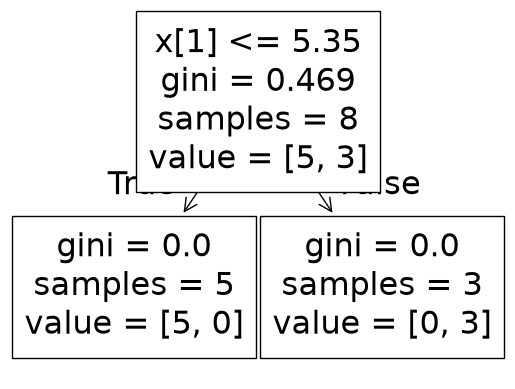

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


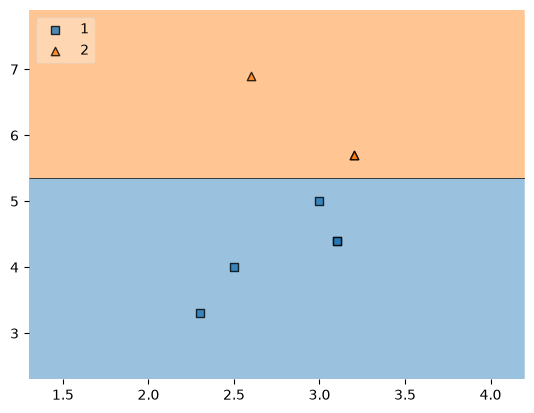

In [30]:
evaluate(dt_bag1,X,y)

In [31]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
65,3.1,4.4,1
118,2.6,6.9,2
120,3.2,5.7,2
89,2.5,4.0,1
147,3.0,5.2,2
77,3.0,5.0,1
65,3.1,4.4,1
120,3.2,5.7,2


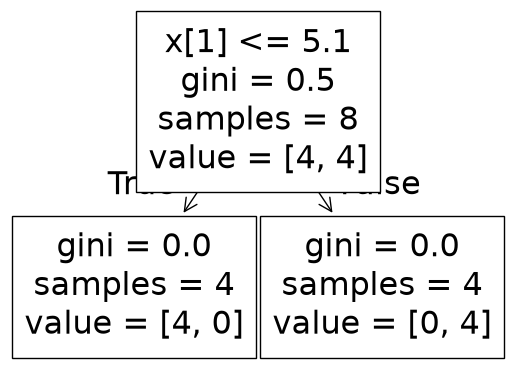

1.0


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


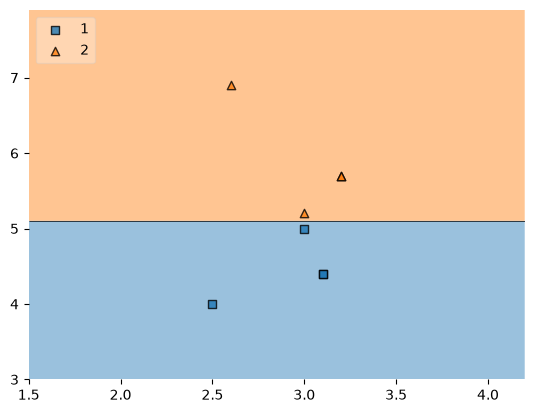

In [32]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [33]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
127,3.0,4.9,2
120,3.2,5.7,2
93,2.3,3.3,1
127,3.0,4.9,2
93,2.3,3.3,1
93,2.3,3.3,1
77,3.0,5.0,1
127,3.0,4.9,2


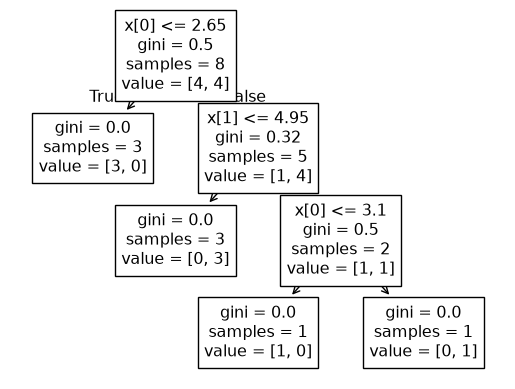

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.4


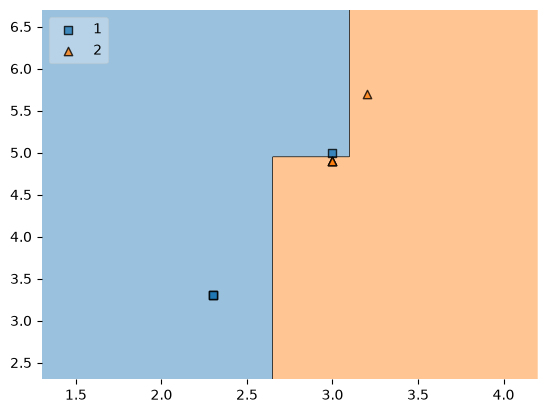

In [34]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [35]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

## Predict

In [36]:
df_test

,SepalWidthCm,PetalLengthCm,Species
132,2.8,5.6,2
50,3.2,4.7,1
139,3.1,5.4,2
73,2.8,4.7,1
70,3.2,4.8,1


In [37]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [1]


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [38]:
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
114,2.8,5.1,2
147,3.0,5.2,2
65,3.1,4.4,1
77,3.0,5.0,1
93,2.3,3.3,1
125,3.2,6.0,2
127,3.0,4.9,2
89,2.5,4.0,1
120,3.2,5.7,2
118,2.6,6.9,2


In [39]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
77,3.0,5.0,1
93,2.3,3.3,1
127,3.0,4.9,2
125,3.2,6.0,2
114,2.8,5.1,2
65,3.1,4.4,1
89,2.5,4.0,1
120,3.2,5.7,2


# Random Subspaces

In [41]:
df1 = pd.read_csv("Iris.csv")
df1 = df1.sample(10)

In [42]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
108,109,6.7,2.5,5.8,1.8,Iris-virginica
1,2,4.9,3.0,1.4,0.2,Iris-setosa
63,64,6.1,2.9,4.7,1.4,Iris-versicolor
84,85,5.4,3.0,4.5,1.5,Iris-versicolor
76,77,6.8,2.8,4.8,1.4,Iris-versicolor
83,84,6.0,2.7,5.1,1.6,Iris-versicolor
126,127,6.2,2.8,4.8,1.8,Iris-virginica
20,21,5.4,3.4,1.7,0.2,Iris-setosa
121,122,5.6,2.8,4.9,2.0,Iris-virginica
25,26,5.0,3.0,1.6,0.2,Iris-setosa


In [43]:
df1.sample(2,replace=True,axis=1)

,Species,SepalLengthCm
108,Iris-virginica,6.7
1,Iris-setosa,4.9
63,Iris-versicolor,6.1
84,Iris-versicolor,5.4
76,Iris-versicolor,6.8
83,Iris-versicolor,6.0
126,Iris-virginica,6.2
20,Iris-setosa,5.4
121,Iris-virginica,5.6
25,Iris-setosa,5.0


# Random Patches

In [44]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
108,109,6.7,2.5,5.8,1.8,Iris-virginica
1,2,4.9,3.0,1.4,0.2,Iris-setosa
63,64,6.1,2.9,4.7,1.4,Iris-versicolor
84,85,5.4,3.0,4.5,1.5,Iris-versicolor
76,77,6.8,2.8,4.8,1.4,Iris-versicolor
83,84,6.0,2.7,5.1,1.6,Iris-versicolor
126,127,6.2,2.8,4.8,1.8,Iris-virginica
20,21,5.4,3.4,1.7,0.2,Iris-setosa
121,122,5.6,2.8,4.9,2.0,Iris-virginica
25,26,5.0,3.0,1.6,0.2,Iris-setosa


In [45]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,PetalWidthCm,Species
84,1.5,Iris-versicolor
63,1.4,Iris-versicolor
20,0.2,Iris-setosa
83,1.6,Iris-versicolor
1,0.2,Iris-setosa
20,0.2,Iris-setosa
108,1.8,Iris-virginica
84,1.5,Iris-versicolor
